# Bank Marketing Analytics & Subscription Prediction

## 01 — Data Quality Assessment and Cleaning

This notebook documents the initial data-quality assessment and the conservative cleaning decisions applied to the UCI Bank Marketing dataset.

### Objectives

- Load the official raw dataset and the cleaned dataset.
- Validate dataset dimensions and schema.
- inspect standard missing values.
- Analyze explicit `unknown` categories.
- Check exact duplicate records.
- Review potential numerical outliers using the IQR rule.
- Validate the encoded target variable.
- Document cleaning decisions and data-leakage considerations.

The reusable cleaning logic is implemented in `src/data_cleaning.py`. This notebook focuses on transparent analysis, validation, and documentation.

In [14]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def locate_project_root(start_path: Path) -> Path:
    """Locate the project root from the current notebook directory."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        cleaning_script = candidate / "src" / "data_cleaning.py"

        if cleaning_script.exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Open the notebook from inside the project directory."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.data_cleaning import (
    OUTLIER_REPORT_PATH,
    OVERVIEW_REPORT_PATH,
    PROCESSED_DATA_PATH,
    UNKNOWN_REPORT_PATH,
    load_raw_data,
    summarize_missing_values,
    validate_raw_schema,
)


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml


## 1. Load the Data and Generated Reports

The raw dataset uses a semicolon delimiter. The cleaned dataset and data-quality reports were generated by the reproducible cleaning script.

In [15]:
raw_data = load_raw_data()
cleaned_data = pd.read_csv(PROCESSED_DATA_PATH)

overview_report = pd.read_csv(OVERVIEW_REPORT_PATH)
unknown_report = pd.read_csv(UNKNOWN_REPORT_PATH)
outlier_report = pd.read_csv(OUTLIER_REPORT_PATH)

validate_raw_schema(raw_data)

print(f"Raw dataset shape: {raw_data.shape}")
print(f"Cleaned dataset shape: {cleaned_data.shape}")

display(cleaned_data.head())

Raw dataset shape: (45211, 17)
Cleaned dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


## 2. High-Level Data-Quality Overview

The overview report compares the raw and cleaned datasets and records the main quality checks performed by the cleaning pipeline.

In [16]:
display(overview_report)

raw_columns = set(raw_data.columns)
cleaned_columns = set(cleaned_data.columns)

print("Removed columns:", sorted(raw_columns - cleaned_columns))
print("Added columns:", sorted(cleaned_columns - raw_columns))

,metric,value
0,raw_rows,45211
1,raw_columns,17
2,cleaned_rows,45211
3,cleaned_columns,17
4,exact_duplicates_found,0
5,exact_duplicates_removed,0
6,raw_missing_cells,0
7,cleaned_missing_cells,0
8,explicit_unknown_values,52124
9,non_subscribers,39922


Removed columns: ['y']
Added columns: ['subscribed']


## 3. Schema and Data Types

The schema inspection helps identify incorrectly parsed numerical columns, unexpected categorical values, and target-encoding issues.

In [17]:
schema_summary = pd.DataFrame(
    {
        "column": cleaned_data.columns,
        "dtype": cleaned_data.dtypes.astype(str).values,
        "non_null_count": cleaned_data.notna().sum().values,
        "unique_values": cleaned_data.nunique(dropna=False).values,
    }
)

display(schema_summary)

,column,dtype,non_null_count,unique_values
0,age,int64,45211,77
1,job,str,45211,12
2,marital,str,45211,3
3,education,str,45211,4
4,default,str,45211,2
5,balance,int64,45211,7168
6,housing,str,45211,2
7,loan,str,45211,2
8,contact,str,45211,3
9,day,int64,45211,31


## 4. Missing-Value Assessment

Standard missing values such as `NaN` are analyzed separately from explicit text categories such as `unknown`.

An `unknown` category may represent unavailable information, a valid operational state, or a previous campaign that did not occur. Therefore, it should not automatically be treated as a standard missing value.

In [18]:
raw_missing_summary = summarize_missing_values(raw_data)

cleaned_missing_summary = pd.DataFrame(
    {
        "column": cleaned_data.columns,
        "missing_count": cleaned_data.isna().sum().values,
        "missing_percentage": (
            cleaned_data.isna()
            .mean()
            .mul(100)
            .round(2)
            .values
        ),
    }
)

print("Raw-data missing values:")
display(
    raw_missing_summary.query("missing_count > 0")
)

print("Cleaned-data missing values:")
display(
    cleaned_missing_summary.query("missing_count > 0")
)

print(
    "Total raw missing cells:",
    int(raw_data.isna().sum().sum()),
)

print(
    "Total cleaned missing cells:",
    int(cleaned_data.isna().sum().sum()),
)

Raw-data missing values:


,column,missing_count,missing_percentage


Cleaned-data missing values:


,column,missing_count,missing_percentage


Total raw missing cells: 0
Total cleaned missing cells: 0


## 5. Explicit `unknown` Categories

The dataset does not contain standard null values, but several categorical columns contain the literal value `unknown`.

These categories are retained because replacing or removing them without additional business context could introduce unsupported assumptions or information loss.

,column,unknown_count,unknown_percentage
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64
4,marital,0,0.00
5,housing,0,0.00
6,default,0,0.00
7,loan,0,0.00
8,month,0,0.00


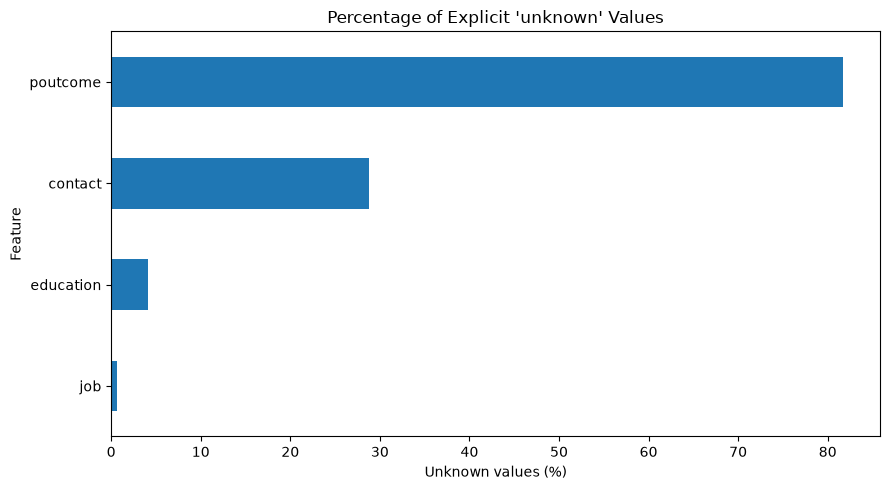

In [19]:
display(unknown_report)

unknown_to_plot = (
    unknown_report
    .query("unknown_count > 0")
    .sort_values("unknown_percentage")
)

ax = unknown_to_plot.plot(
    x="column",
    y="unknown_percentage",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)

ax.set_title("Percentage of Explicit 'unknown' Values")
ax.set_xlabel("Unknown values (%)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## 6. Exact Duplicate Assessment

Exact duplicates are records where every feature and the target value are identical.

No exact duplicate records were found in this dataset. Therefore, the number of rows remained unchanged after cleaning.

In [20]:
raw_duplicate_count = int(raw_data.duplicated().sum())
cleaned_duplicate_count = int(cleaned_data.duplicated().sum())

print(f"Raw exact duplicates: {raw_duplicate_count}")
print(f"Cleaned exact duplicates: {cleaned_duplicate_count}")

Raw exact duplicates: 0
Cleaned exact duplicates: 0


## 7. Numerical Summary and Potential Outliers

The IQR rule is used as a diagnostic tool to identify unusual numerical observations.

An IQR flag does not prove that a value is erroneous. Banking variables such as balance, campaign contacts, call duration, and previous-contact history may naturally have skewed or zero-inflated distributions.

Potential outliers are therefore reported but not automatically removed.

In [21]:
numeric_columns = cleaned_data.select_dtypes(
    include="number"
).columns

display(
    cleaned_data[numeric_columns]
    .describe()
    .transpose()
)

display(outlier_report)

,count,mean,std,min,25%,50%,75%,max
age,"45,211.00",40.94,10.62,18.00,33.00,39.00,48.00,95.00
balance,"45,211.00","1,362.27","3,044.77","-8,019.00",72.00,448.00,"1,428.00","102,127.00"
day,"45,211.00",15.81,8.32,1.00,8.00,16.00,21.00,31.00
duration,"45,211.00",258.16,257.53,0.00,103.00,180.00,319.00,"4,918.00"
campaign,"45,211.00",2.76,3.10,1.00,1.00,2.00,3.00,63.00
pdays,"45,211.00",40.20,100.13,-1.00,-1.00,-1.00,-1.00,871.00
previous,"45,211.00",0.58,2.30,0.00,0.00,0.00,0.00,275.00
subscribed,"45,211.00",0.12,0.32,0.00,0.00,0.00,0.00,1.00


,column,q1,q3,iqr,lower_bound,upper_bound,potential_outlier_count,potential_outlier_percentage
0,age,33.00,48.00,15.00,10.50,70.50,487,1.08
1,balance,72.00,"1,428.00","1,356.00","-1,962.00","3,462.00",4729,10.46
2,day,8.00,21.00,13.00,-11.50,40.50,0,0.00
3,duration,103.00,319.00,216.00,-221.00,643.00,3235,7.16
4,campaign,1.00,3.00,2.00,-2.00,6.00,3064,6.78
5,pdays,-1.00,-1.00,0.00,-1.00,-1.00,8257,18.26
6,previous,0.00,0.00,0.00,0.00,0.00,8257,18.26


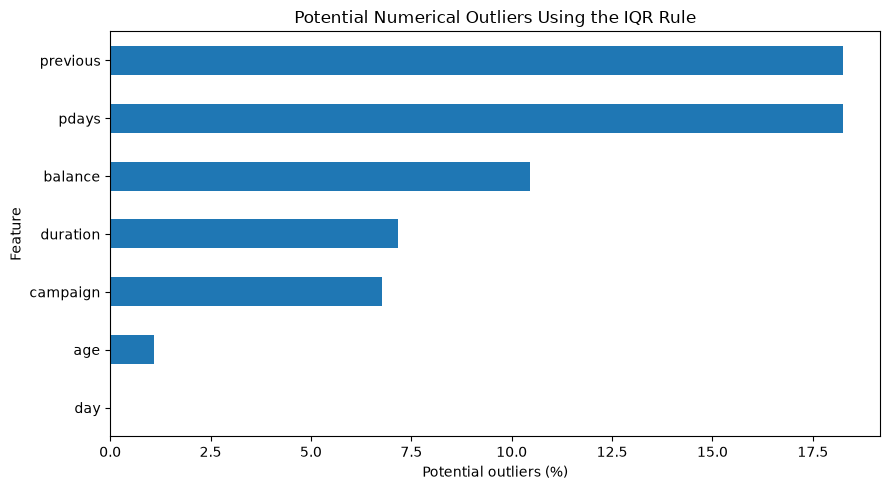

In [22]:
outlier_plot_data = (
    outlier_report
    .sort_values("potential_outlier_percentage")
)

ax = outlier_plot_data.plot(
    x="column",
    y="potential_outlier_percentage",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)

ax.set_title("Potential Numerical Outliers Using the IQR Rule")
ax.set_xlabel("Potential outliers (%)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## 8. Target Encoding and Class Distribution

The original target column `y` used text values:

- `no`: the client did not subscribe.
- `yes`: the client subscribed.

The cleaned dataset uses:

- `0`: non-subscriber.
- `1`: subscriber.

The target is imbalanced, so accuracy alone will not be sufficient for evaluating future classification models.

,subscribed,label,count,percentage
0,0,No subscription,39922,88.30
1,1,Subscription,5289,11.70


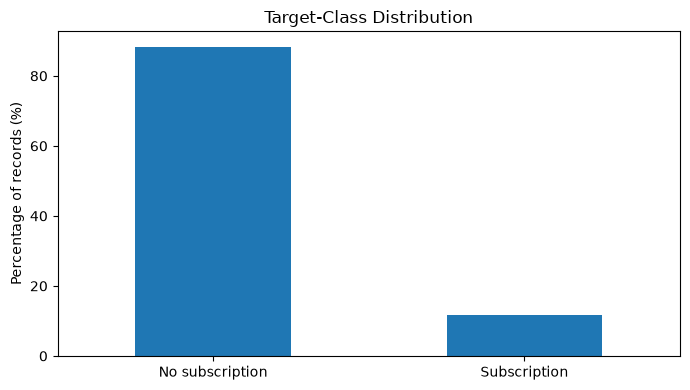

In [23]:
target_distribution = (
    cleaned_data["subscribed"]
    .value_counts()
    .sort_index()
    .rename_axis("subscribed")
    .reset_index(name="count")
)

target_distribution["label"] = (
    target_distribution["subscribed"]
    .map(
        {
            0: "No subscription",
            1: "Subscription",
        }
    )
)

target_distribution["percentage"] = (
    target_distribution["count"]
    .div(len(cleaned_data))
    .mul(100)
    .round(2)
)

display(
    target_distribution[
        [
            "subscribed",
            "label",
            "count",
            "percentage",
        ]
    ]
)

ax = target_distribution.plot(
    x="label",
    y="percentage",
    kind="bar",
    legend=False,
    figsize=(7, 4),
)

ax.set_title("Target-Class Distribution")
ax.set_xlabel("")
ax.set_ylabel("Percentage of records (%)")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 9. Cleaning Decisions

The following conservative decisions were applied:

1. Column names and categorical text were normalized to lowercase and stripped of surrounding whitespace.
2. The original target column `y` was encoded as the binary column `subscribed`.
3. Exact duplicate rows would be removed, but none were found.
4. Explicit `unknown` categories were retained as separate categorical levels.
5. Potential numerical outliers were reported but not automatically removed.
6. Negative account balances were retained because overdrafts or debt may be legitimate banking values.
7. The value `pdays = -1` was retained as a meaningful sentinel representing no previous contact.
8. The `duration` feature was retained for exploratory analysis.
9. The deployable pre-call prediction model will exclude `duration` because call duration is unknown before the call ends and could cause data leakage.

## 10. Automated Validation Checks

These assertions verify the core assumptions required before continuing to exploratory data analysis.

In [24]:
assert raw_data.shape == (45_211, 17)
assert cleaned_data.shape == (45_211, 17)

assert "y" in raw_data.columns
assert "y" not in cleaned_data.columns
assert "subscribed" in cleaned_data.columns

assert set(raw_data["y"].unique()) == {"no", "yes"}
assert set(cleaned_data["subscribed"].unique()) == {0, 1}

assert int(raw_data.duplicated().sum()) == 0
assert int(cleaned_data.duplicated().sum()) == 0

assert int(raw_data.isna().sum().sum()) == 0
assert int(cleaned_data.isna().sum().sum()) == 0

assert int((cleaned_data["subscribed"] == 0).sum()) == 39_922
assert int((cleaned_data["subscribed"] == 1).sum()) == 5_289

assert (cleaned_data["age"] > 0).all()
assert cleaned_data["day"].between(1, 31).all()
assert (cleaned_data["duration"] >= 0).all()
assert (cleaned_data["campaign"] >= 1).all()
assert (cleaned_data["pdays"] >= -1).all()
assert (cleaned_data["previous"] >= 0).all()

print("All data-quality validation checks passed successfully.")

All data-quality validation checks passed successfully.


## 11. Data-Quality Summary

The official dataset was loaded and validated successfully.

Key findings:

- The dataset contains 45,211 records and 17 columns.
- No exact duplicate rows were found.
- No standard null values were detected.
- Explicit `unknown` values occur mainly in `poutcome` and `contact`.
- Potential numerical outliers are present, but they were not automatically removed.
- The target has a substantial class imbalance: approximately 11.7% of clients subscribed.
- The cleaned target is stored as the binary column `subscribed`.
- The `duration` feature will be excluded from the primary pre-call machine-learning model to prevent data leakage.

The cleaned dataset is ready for exploratory data analysis.